# Проект SocialSearch

## Тематические статьи
Про графы:
- [Хорошая статья на хабре про кластеризацию графив](https://habr.com/ru/company/dca/blog/265077/)
- [алгоритм louvain](https://louvain-igraph.readthedocs.io/en/latest/index.html)
- [Awesome Community Detection Research Papers](https://github.com/benedekrozemberczki/awesome-community-detection)


Про нахождение информации о человеке:
- https://bsfo.ru/threads/probiv-cheloveka-v-vk.4110/
- https://www.iphones.ru/iNotes/705983
- https://cryptoworld.su/5-sposobov-probit-informaciyu-o-cheloveke-v-seti/
- https://habr.com/en/company/echelon/blog/321754/ Отличная статья на хабре
    
    
Лайфкаки по поиску информации:
- https://vk.com/feed?obj=1&q=&section=mentions
- [Каталог пользователей вк](https://vk.com/catalog.php)
- https://vk.com/foaf.php?id=245089915 Посмотреть код страницы
- http://сервисы.гувм.мвд.рф/info-service.htm?sid=2000 Провека действительности паспорта

Конкуренты (похожие проекты):
- https://bazaman.ru/ Нахождение человека по данным. Работает хреново
- https://poiski-people.ru/instrukziya.html Плохо работает [То, что нашли обо мне](https://poiski-people.ru/rossiya/moskva/boris-novichkov-moskva-90185.html) 
- https://people.yandex.ru (Поиск людей по различной информации)
- https://poisk-help.ru/ Работает плохо [Обо мне](https://poisk-help.ru/rossiya/moskva/boris-novichkov-moskva-2959.html)
- http://spys.one/vk/ Банальное копирование вк. Только информация со страницы пользователя
- https://vk.barkov.net/userinfo.aspx Требует доступ к странице. Базовая информация

Получение ключа доступа пользователя для vk api
https://oauth.vk.com/authorize?client_id=7091370&scope=photos,audio,video,docs,notes,pages,status,offers,questions,wall,groups,notifications,stats,ads,offline,docs,pages,stats,notifications,wall,friends&response_type=token

# Задачи проекта: 
1. Найти человека по минимальномо количеству известных о нем данных
2. Получить всю возможную инфомацию о человеке из открытых источников (социальные сети, гос. порталы, гугл, некоторые сайты)
3. Проанализировать (аналитичестки, с помощью ML) 
4. Предоставить все в красивом человеко-читаемом виде конечному потребителю (пользователю данного ресурса)

## Информация о человеке
### Базовые аспекты
*Поля страницы вк: first_name, last_name, photo_200, sex, bdate, city, country, relatives, home_town, maiden_name, relation*
- Имя
- Вевичья фамилия
- Фото
- Пол
- Возраст
- Страна
- Родной город
- Родственники


### Основная деятельность (в настоящем / прошлом)
*Поля страницы вк: career, education, occupation, schools, universities, military*
- Школа (класс, год)
- Вуз (факультет, курс, год)
- Работа (направленность, год)
- Бизнес (направления, сайт и пр)

### Сетевая жизнь / Контакты
*Поля страницы вк: nickname, online, site, exports, contacts, verified, last_seen, connections, followers_count*
- Сайт
- Все социальные сети
- Подписчики
- Verify
- Приватный аккаунт

### Интересы / Занятия
*Поля страницы вк: books, activities, movies, music, tv, trending, games, interests, quotes*
- Увлечения
- Хобби
- Музыка Фильмы Игры Книги

### Характеристика / Анализ
*Поля страницы вк: status, counters, personal, about*

*Информация на основе всех имеющихся данных*
- Экстраверт / Интроверт (в процентах)
- Популярность в сети (Подписчики, друзья и тд)
- Сетевая доступность (в процентах). Количество личной информации в сети
- Общественный статус (один из нескольких вариантов)
- Процент одиночных друзей (не состоящих в сообществах испытуемого)
- Придумать еще что-нибудь!

## Социальные сообщества человека
**Любые группы людей, к которым относится испытуемый:**
- Социальные объединения среди друзей
- Сообщества на основе общих групп
- Виртуальное объединение на основе общего интереса (несвязные друзья программисты)

### Операции над сообществами
- Поиск полного коллектива из небольшой его части

### Параметры каждого объединения
- Список всех объединяющих коллектив факторы (место учебы, интересы, возраст, пол и пр)
- Связность сообщества (исходя из графа)
- Размер сообщества (количество участников)
- Тут можно много чего еще придумать!


In [1]:
import numpy as np
import pandas as pd
from skimage import io
import networkx as nx
import random
import matplotlib.pyplot as plt
import vk
from community_pool import Community
import warnings
warnings.filterwarnings("ignore")

import collections
from collections import Counter
import datetime
from time import time
import functools
from vkuser import VKUser
import networkx as nx
import math
from main import *

In [2]:
# %matplotlib qt
%matplotlib inline
user = VKUser('boris2000n')
# user.groups.show_graph()
# user.groups.color_graph(algorithm='label_propagation')
# user.groups.color_graph()
# user.groups.pools()[0].print()
# user.friends.params
# user.groups.graph.edges[(126083726, 185185742)]['weight']
user.groups.graph

* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: %s groups
* VK API Request: 

In [33]:
id = '602'
items = user.groups.pools() + user.friends.pools()
pools_dict = dict([(item.id, item) for item in items])
pool1 = pools_dict[id]
pool1.print()
# pool1.params
# pool1.params['groups_pages_activity']

KeyError: '602'

In [32]:
i = 1
user.groups.pools()[i].print()
# user.groups.pools()[i].params['groups_pages_activity'].most_common()


анекдотов.net 22222333 https://vk.com/anekdot
Политика Путина 23977193 https://vk.com/kremlin_rf
Гифки 26005665 https://vk.com/club26005665
Эта весёлая Россия 36959483 https://vk.com/vk.policyhumor
География в опросах 73484869 https://vk.com/z_nature
Взрослый Юмор 99800441 https://vk.com/humor_tev
Вездеходы 111205860 https://vk.com/vezdexood
Подслушано Метро Москвы 144260965 https://vk.com/pmmgo
Добрые мемы : ) 147286578 https://vk.com/dobriememes
ШВТ 152219848 https://vk.com/shvt
Рассказано 153286036 https://vk.com/narrated
Закрытая афиша Москвы 154852658 https://vk.com/mosctop
За кадром 163182607 https://vk.com/vip_pub777


In [ ]:
ne_groups = Counter(
                        dict(
                            [
                                (node_group[nei], graph.edges[(node, nei)].get('weight', 1))
                                for nei in graph.neighbors(node)
                            ]
                        )
                    )

In [19]:
from sklearn.preprocessing import normalize
x = np.random.rand(5)*10
norm1 = x / np.linalg.norm(x)
norm2 = normalize(x[:,np.newaxis], axis=0).ravel()
norm1

array([0.37320257, 0.70729868, 0.14509851, 0.55634512, 0.17284372])

In [41]:
my_groups = user.groups_pool.groups_data
my_groups = sorted(my_groups, key=lambda x: x['members_count'])
groups = np.array([(gr['members_count'], gr['name']) for gr in my_groups])
print(groups)
# np.median(groups[:,0])
median = np.median(groups[:,0].astype(int)).astype(int)
dict(groups)[str(median)]

[['3' 'mdd test']
 ['119' 'Telarld']
 ['174' 'Официальная страница журнала "Ростки Ковчега"']
 ['186' 'Просмотры и трансляции ФИВТ']
 ['296' 'Алексей Кириллов. Портретный и семейный фотограф']
 ['351' 'ФПМИ.Индустрия 1 курс']
 ['440' 'Академия искусственного интеллекта']
 ['448' 'фтл каждый день']
 ['527' 'Театр-студия "МАЛАХИТ" Олега Малахова']
 ['598' 'Фонд целевого капитала МФТИ']
 ['602' 'День Первокурсника МФТИ 2019']
 ['1056' 'Учебные материалы ФИВТ (Оф. клуб любителей Го)']
 ['1217' 'Семейная школа поселения родовых поместий Ковчег']
 ['1246' 'CulturALL Reboot']
 ['1295' 'Питомник-БотСад-Поместье | сеянцы, саженцы |']
 ['1413' 'Абитуриенты ФПМИ МФТИ']
 ['1617' 'Студсовет ФИВТ']
 ['1870' 'Soft skills в МФТИ']
 ['1916' 'MIPT(Moscow Institute of Physics and Technology)']
 ['2003' 'Физтех Тур']
 ['2013' 'клуб любителей дискретной постиронии']
 ['2039' 'ФПМИ МФТИ']
 ['2584' 'СНПО «Бакалавры Физтеха»']
 ['2767' 'Экопоселение Родовых Поместий КОВЧЕГ']
 ['3233' 'Codeforces']
 ['3895' 'П

'VK Education'

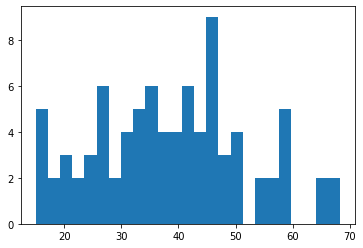

40.12472437003373

In [56]:
%matplotlib inline
user = VKUser('https://vk.com/didiv2000')
#user.friends_com.color_communities(user.friends_com.split())
plt.hist(user.friends_com.params['age_list'], bins=25)
plt.show()
user.friends_com.params['age_median']

In [7]:
activities_types = Counter()

In [10]:
for i in range(1000):
    print("LOOP", i)
    try:
        user = VKUser.get_random_user()
#         user.print()
#         user.friends_com.show_graph()
#         comms = user.get_communities()
        com = user.friends_com
#         for com in comms:
        items = list(com.community_groups.from_most_common(25).params['groups_pages_activity'])
        activities_types += Counter(items)
        print(len(list(activities_types)))
    except:
        user.print()

LOOP 0
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
295
LOOP 1
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
295
LOOP 2
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Светлана Лепехова 206988099 https://vk.com/id206988099
LOOP 3
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s execute
* VK API Request: %s execute
295
LOOP 4
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Мар

* VK API Request: %s friends
* VK API Request: %s execute
Анастасия Лопатнева 293763653 https://vk.com/id293763653
LOOP 44
* VK API Request: %s users
* VK API Request: %s friends
15. Access denied: this profile is private. request_params = {'method': 'friends.get', 'oauth': '1', 'v': '5.35', 'lang': 'ru', 'user_id': '297336668'}
* VK API Request: %s execute
Olesya Stepanenko 297336668 https://vk.com/id297336668
LOOP 45
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Dada Da 95694926 https://vk.com/id95694926
LOOP 46
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s execute
298
LOOP 47
* VK API Request: %s users
* VK API Request: %s friends
15. Access denied: this profile is private. request_params = {'method': 'friends.get', 'oauth': '1', 'v': '5.35', 'lang': 'ru', 'user_id'

* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
303
LOOP 81
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Елена Шишкина 82153157 https://vk.com/id82153157
LOOP 82
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
303
LOOP 83
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
303
LOOP 84
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
303
LOOP 85
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
303
LOOP 86
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s e

* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
Ефим Попов 81467773 https://vk.com/id81467773
LOOP 126
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
309
LOOP 127
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
309
LOOP 128
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s execute
* VK API Request: %s execute
309
LOOP 129
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Ксения Лузина 114889273 https://vk.com/id114889273
LOOP 130
* VK API Request: %s users
* VK API Request: %s friends
* V

* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
312
LOOP 163
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
312
LOOP 164
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Анюта Тростникова 133896106 https://vk.com/id133896106
LOOP 165
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Виктор Кочкарев 95750156 https://vk.com/id95750156
LOOP 166
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Код Крушитель 276447667 https://vk.com/id276447667
LOOP 167
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. 

...

* VK API Request: %s execute
355
LOOP 792
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Нелька Акаева 214238056 https://vk.com/id214238056
LOOP 793
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
355
LOOP 794
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
355
LOOP 795
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
355
LOOP 796
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Harry Kaler 411592968 https://vk.com/id411592968
LOOP 797
* VK API Request: %s users
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: 

VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
357
LOOP 833
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Милли Милливна 82453833 https://vk.com/id82453833
LOOP 834
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
357
LOOP 835
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Сергей Замарайкин 51349512 https://vk.com/id51349512
LOOP 836
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Лика Акил 235998762 https://vk.com/id235998762
LOOP 837
* VK API Request: %s users
* VK API Request: %s friends
15. Access denied: this profile is private. request_params = {'method': 'friend

* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
361
LOOP 878
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
361
LOOP 879
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Евгений Васильев 139620996 https://vk.com/id139620996
LOOP 880
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
Victoria Vega 291078020 https://vk.com/id291078020
LOOP 881
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
361
LOOP 882
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Скоро Лето 24077813 https://vk.com/id24077813
LOOP 883
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
361
LOOP 884
* VK API Request: %s user

* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
366
LOOP 920
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Анечка Котя 58055061 https://vk.com/id58055061
LOOP 921
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
366
LOOP 922
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Vitalik Bugreev 223709488 https://vk.com/id22370948

* VK API Request: %s friends
15. Access denied: this profile is private. request_params = {'method': 'friends.get', 'oauth': '1', 'v': '5.35', 'lang': 'ru', 'user_id': '41558990'}
* VK API Request: %s execute
Григорий Кушнаренко 41558990 https://vk.com/id41558990
LOOP 961
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Вован Денисов 17947740 https://vk.com/id17947740
LOOP 962
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Sergey Dulov 242928900 https://vk.com/id242928900
LOOP 963
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Дмитрий Щёголев 134478944 https://vk.com/id134478944
LOOP 964
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
Rufat Gasanov 96193792 https://vk.com/id96193792
LOOP 965
* VK API Request: %s users
*

In [15]:
print(len(activities_types))
activities_types.most_common()

370


[('Юмор', 860),
 ('Кино', 608),
 ('Городское сообщество', 563),
 ('Интернет-СМИ', 448),
 ('Обмен музыкой', 416),
 ('Творчество', 368),
 ('Публичная страница', 348),
 ('Кулинария, рецепты', 342),
 ('Литература', 304),
 ('Отношения полов', 276),
 ('Уход за собой', 255),
 ('Образование', 255),
 ('Наука', 251),
 ('ВКонтакте', 244),
 ('Объявления', 244),
 ('Общество', 235),
 ('Молодёжное движение', 224),
 ('Шоу, передача', 211),
 ('Бизнес', 209),
 ('Знакомства', 200),
 ('Здоровый образ жизни', 193),
 ('Философия', 190),
 ('Стиль, одежда, обувь', 186),
 ('Фотография', 166),
 ('Туризм, путешествия', 162),
 ('Автомобили', 148),
 ('Дизайн интерьера', 147),
 ('Музыка', 143),
 ('Игры', 134),
 ('Телеканал', 129),
 ('Родители и дети', 126),
 ('Фитнес', 125),
 ('Культура', 102),
 ('Друзья', 99),
 ('СМИ', 95),
 ('Строительство, ремонт', 89),
 ('Поиск работы', 88),
 ('Вымышленный персонаж', 86),
 ('Сайты', 85),
 ('Искусство и развлечения', 78),
 ('Rap, Hip-Hop', 74),
 ('Футбол', 74),
 ('Дискуссионный 

In [1]:
print(len(activities_types))
activities_types.most_common()

NameError: name 'activities_types' is not defined

In [2]:
url = 'boris2000n'
user = VKUser(url)
comms = user.get_communities()
# user.friends_com.color_communities(comms)
# sum([com.size for com in comms])
# user.friends_com.size

* VK API Request: %s execute
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute


In [12]:
def getLikes(user_id, cnt, api):
    import time
    # подписки пользователя
    subscriptions_list = api.users.getSubscriptions(user_id=user_id,extended=0)['groups']['items']
    # формируем список id, который нужно передать в следующий метод
    groups_list = ['-' + str(x) for x in subscriptions_list]
    posts = {}
    # формируем ленту новостей
    newsfeed = api.newsfeed.get(
        filters='post',
        source_ids=', '.join(groups_list),
        count=100, timeout=10)
    # добавляем посты в словарь в формате id_поста: id_группы
    posts.update({x['post_id']: x['source_id'] for x in newsfeed['items']})
    # нужно для получения следующей партии
    # если требуется более одного запроса — делаем остаток в цикле
    if cnt != 1:
        for c in range(cnt - 1):
            next_from = newsfeed['start_from']
            kwargs = {
                'from': next_from,
                'filters': 'post',
                'source_ids': ', '.join(groups_list),
                'count': 100,
                'timeout': 10
            }
            newsfeed = api.newsfeed.get(**kwargs)
 
            posts.update({x['post_id']: x['source_id'] for x in newsfeed['items']})
#             time.sleep(1)
    liked_posts = []
 
    print('Лайкнутые посты:')
    for post in posts.items():
        try:
            itemID = post[0]
            ownerID = post[1]
            timeOut = 5
            isLiked = api.likes.isLiked(
                user_id=user_id,
                item_id=itemID,
                type='post',
                owner_id=ownerID,
                timeout=timeOut)['liked']
        except Exception:
#             print('ERROR! ' + 'vk.com/wall{0}_{1}'.format(post[1], post[0]))
            isLiked = 0
#         print(isLiked)
        if isLiked:
#             liked_posts.append('vk.com/wall{0}_{1}'.format(post[1], post[0]))
            print('https://vk.com/wall{}_{}'.format(post[1], post[0]))
            time.sleep(0.25)
    return liked_posts
getLikes(user.vkid, 0, bapi.api_user)

* VK API Request: %s users
* VK API Request: %s newsfeed
Лайкнутые посты:
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK AP

[]

## Выявление сообществ на графе друзей испытуемого

In [21]:
G = user.friends.graph

## Отрисовка разделенного на сообщества графа друзей

## Нахождение полного сообщества по нескольким участникам

In [651]:
base_community = np.array(a[1])

In [14]:
def print_func_plot(func, params, x=None):
    results = []
    for args in params:
        results.append(func(**args))
    if x is None:
        x = range(len(results))
    plt.plot(x, results)
    plt.show()

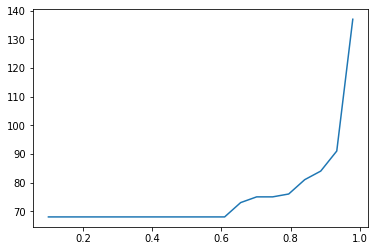

In [318]:
x = np.linspace(0.1, 0.98, num=20)
print_func_plot(
    get_community_size, 
    [
        {
            'weight_reduction_ratio': i,
            'break_point': 10,
        }
        for i in x
    ],
    x=x
)

## Нахождение общего знаменателя среди сообщества (школа, вуз, место жительста, группы вк и т.д)

In [1]:
from community import Community
Community.generate_random(20).print_users(5)

Serj Karaush https://vk.com/id413176842 
Эльвира Марсова https://vk.com/id404693545 
Евгений Добрый https://vk.com/id349755405 
Борис Юльметьев https://vk.com/id175167265 
Ира Туманова https://vk.com/id228994866 


In [679]:
# comm1 = Community.from_nodes_part(base_community)
# comm1.print_users(2)

Никита Брюзгин https://vk.com/id166141735 
Елизавета Шерстнёва https://vk.com/id170099909 


In [709]:
Community.from_nodes_part([my_id, 269339915, 493754172, 211915613], 
                          weight_reduction_ratio=0.5, break_point=3).get_special_params()

* Get user data 245520002
* Get user data 372043906
* Get user data 190016644
* Get user data 344735749
* Get user data 125646982
* Get user data 295948807
* Get user data 437530634
* Get user data 269339915
* Get user data 265405579
* Get user data 193795087
* Get user data 344871324
* Get user data 155987360
* Get user data 504638756
* Get user data 20352294
* Get user data 123543974
* Get user data 195097896
* Get user data 314043174
* Get user data 453566375
* Get user data 235933101
* Get user data 493754172
* Get user data 231293500
* Get user data 200109760
* Get user data 199148993
* Get user data 402705610
* Get user data 157185614
* Get user data 415803087
* Get user data 396970062
* Get user data 13759701
* Get user data 341467094
* Get user data 230749912
* Get user data 211915613
* Get user data 415808612
* Get user data 140878439
* Get user data 272023406
* Get user data 271552501


{'community_size': 36,
 'sex_mean': 1.6944444444444444,
 'age_median': 18.532233380395013,
 'city_first_fr': 0.5,
 'country_first_fr': 0.7222222222222222,
 'online_mean': 0.1388888888888889,
 'online_mobile_mean': 1.0,
 'verified_mean': 0.0,
 'last_seen_mean': 0.47183191654265055,
 'last_seen_amax': 1.9163202021767696,
 'last_seen_median': 0.07136649847306586,
 'site_fr': 0.1388888888888889,
 'followers_count_mean': 68.5,
 'followers_count_median': 47.0,
 'followers_count_amax': 309.0,
 'home_town_first_fr': 0.19444444444444445,
 'occupation_type_first_fr': 0.1388888888888889,
 'occupation_name_first_fr': 0.027777777777777776,
 'personal_langs_first_fr': 0.2777777777777778,
 'personal_political_first_fr': 0.027777777777777776,
 'personal_religion_first_fr': 0.027777777777777776,
 'personal_people_main_first_fr': 0.1111111111111111,
 'personal_smoking_first_fr': 0.08333333333333333,
 'personal_alcohol_first_fr': 0.05555555555555555,
 'personal_life_main_first_fr': 0.08333333333333333,
 

In [583]:
from tqdm import tqdm_notebook as tqdm
for i in tqdm(range(2)):
    size = np.random.randint(20, 250)
    params = Community.generate_random(size).get_special_params()
#     print(params)
    CommunityData.create(data=params)

In [584]:
comm_data = [i.data for i in CommunityData.select().execute()]
def param_list(key):
    return [x[key] for x in comm_data]
params = ['community_size', 'sex_mean', 'age_median', 'city_first_fr', 
'country_first_fr', 'online_mean', 'online_mobile_mean', 
'verified_mean', 'last_seen_mean', 'last_seen_amax', 
'last_seen_median', 'site_fr', 'followers_count_mean', 
'followers_count_median', 'followers_count_amax', 'home_town_first_fr', 
'occupation_type_first_fr', 'occupation_name_first_fr', 'personal_langs_first_fr', 
'personal_political_first_fr', 'personal_religion_first_fr', 'personal_people_main_first_fr', 
'personal_smoking_first_fr', 'personal_alcohol_first_fr', 'personal_life_main_first_fr', 
'relatives_childs_fr', 'relation_first_fr', 'schools_first_fr', 
'schools_type_str_first_fr', 'status_fr']

community_size


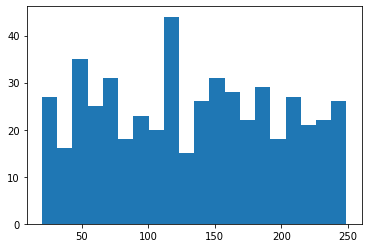

sex_mean


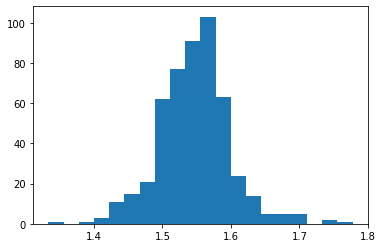

age_median


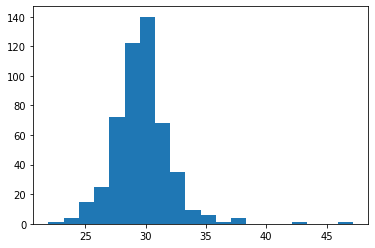

city_first_fr


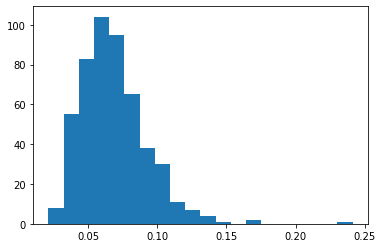

country_first_fr


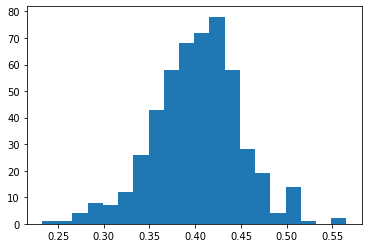

online_mean


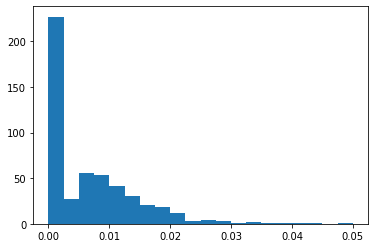

online_mobile_mean


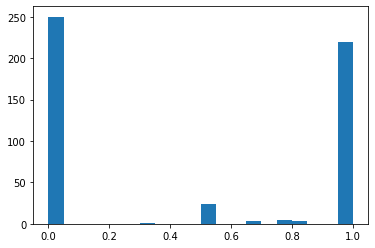

verified_mean


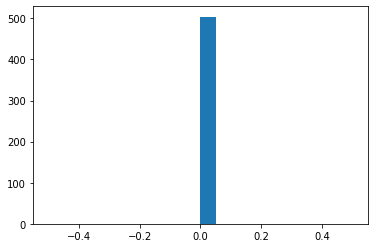

last_seen_mean


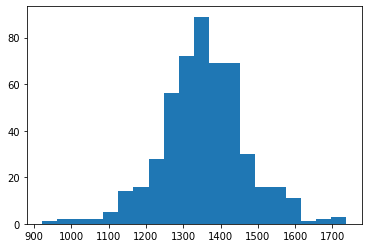

last_seen_amax


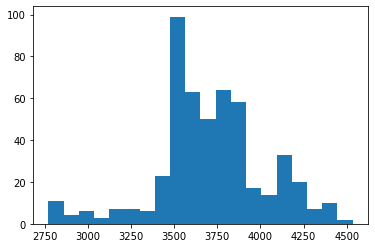

last_seen_median


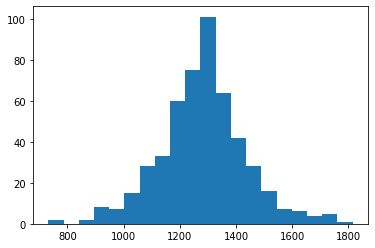

site_fr


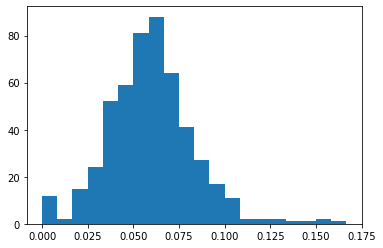

followers_count_mean


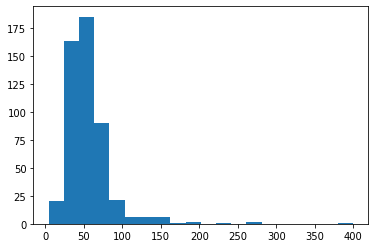

followers_count_median


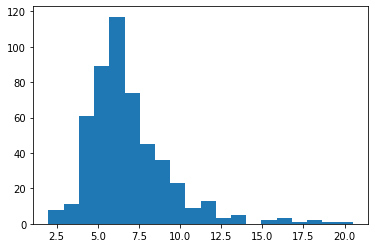

followers_count_amax


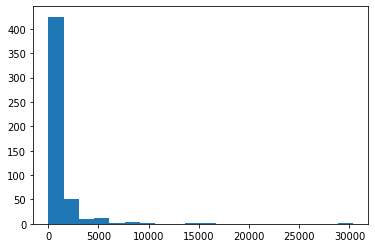

home_town_first_fr


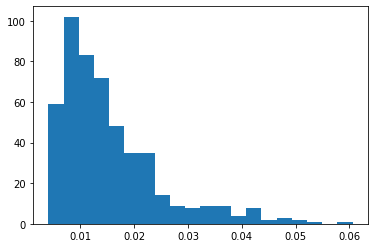

occupation_type_first_fr


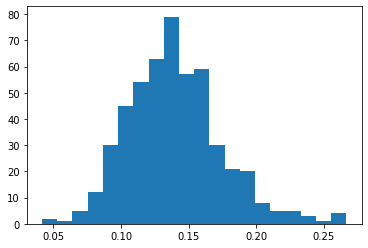

occupation_name_first_fr


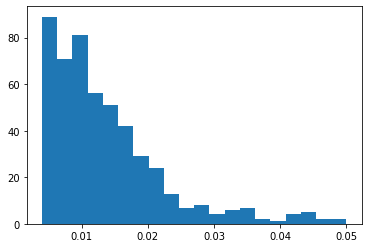

personal_langs_first_fr


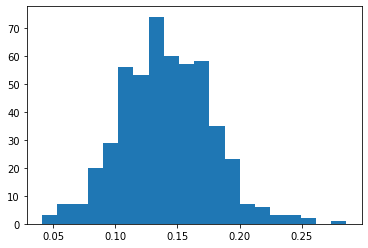

personal_political_first_fr


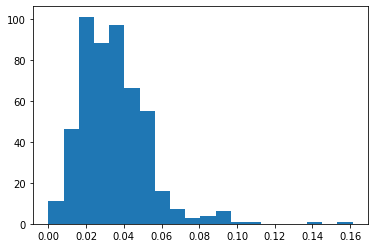

personal_religion_first_fr


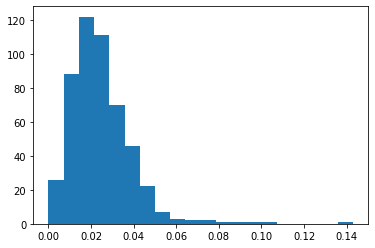

personal_people_main_first_fr


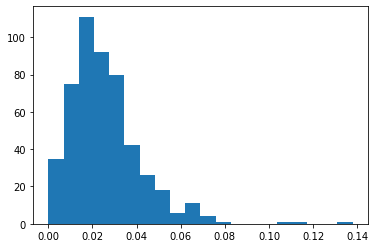

personal_smoking_first_fr


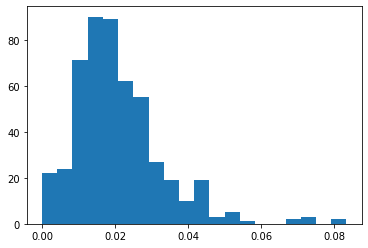

personal_alcohol_first_fr


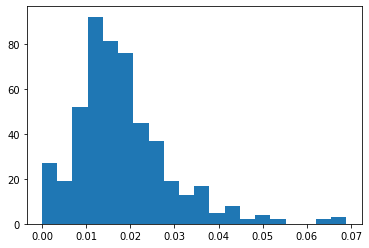

personal_life_main_first_fr


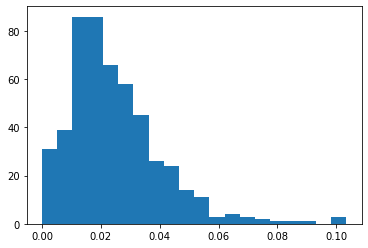

relatives_childs_fr


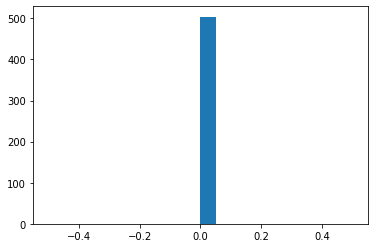

relation_first_fr


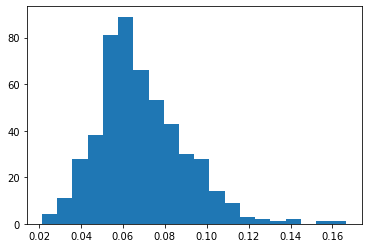

schools_first_fr


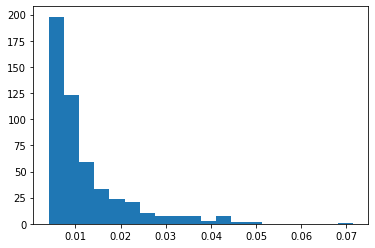

schools_type_str_first_fr


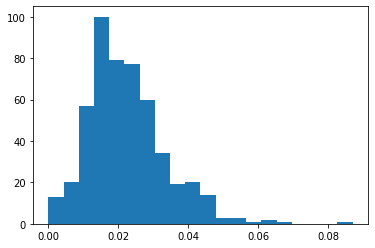

status_fr


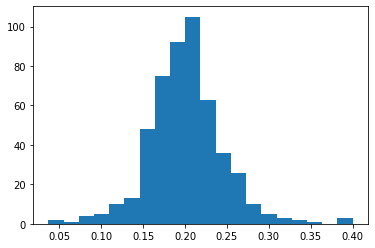

In [680]:
# Community.generate_random(1).special_params
for p in params:
    print(p)
    l = param_list(p)
    plt.hist(l, 20)
    plt.show()

In [681]:
key_importance = []
target_community = comm1.get_params()

for key in params:
    target_element = target_community[key]
#     print(target_element)
    hist_list = param_list(key)
    bins = 10
    hist_values, hist_x = np.histogram(hist_list, bins)
#     plt.hist(hist_list, bins)
#     plt.show()
#     print(hist_x)
    if target_element < hist_x[0]:
        hist_value = 0
    elif target_element > hist_x[-1]:
        hist_value = 0
    else:
        hist_column = np.where(hist_x <= target_element)[0][-1]
        hist_value = hist_values[hist_column]

    hist_max = np.max(hist_values)
    element_importance = hist_value / hist_max
    key_importance.append((element_importance, key))
#     print(hist_max)
#     print(element_fr)
[print(i) for i in sorted(key_importance)]
None

* Get user data 229170215
* Get user data 2384937
* Get user data 327191868
* Get user data 1727556
* Get user data 150879566
* Get user data 349087825
* Get user data 305752720
* Get user data 280349348
* Get user data 332072868
* Get user data 179897523
* Get user data 203419100
(0.0, 'age_median')
(0.0, 'city_first_fr')
(0.0, 'country_first_fr')
(0.0, 'followers_count_median')
(0.0, 'home_town_first_fr')
(0.0, 'last_seen_amax')
(0.0, 'last_seen_mean')
(0.0, 'last_seen_median')
(0.0, 'occupation_name_first_fr')
(0.0, 'occupation_type_first_fr')
(0.0, 'online_mean')
(0.0, 'schools_first_fr')
(0.0, 'schools_type_str_first_fr')
(0.0, 'status_fr')
(0.012, 'online_mobile_mean')
(0.07692307692307693, 'site_fr')
(0.09818181818181818, 'followers_count_mean')
(0.13664596273291926, 'personal_smoking_first_fr')
(0.20382165605095542, 'personal_alcohol_first_fr')
(0.21674876847290642, 'personal_people_main_first_fr')
(0.2261904761904762, 'sex_mean')
(0.23622047244094488, 'personal_langs_first_fr'

In [43]:
def once_property(func):
    @property
    def wrapper(class_obj, *args, **kwargs):
        func_name = func.__name__
        class_value_name = f'{func_name}_'
        if hasattr(class_obj, class_value_name):
            return getattr(class_obj, class_value_name)
        method_result = func(class_obj, *args, **kwargs)
        setattr(class_obj, class_value_name, method_result)
        return method_result
    return wrapper

7


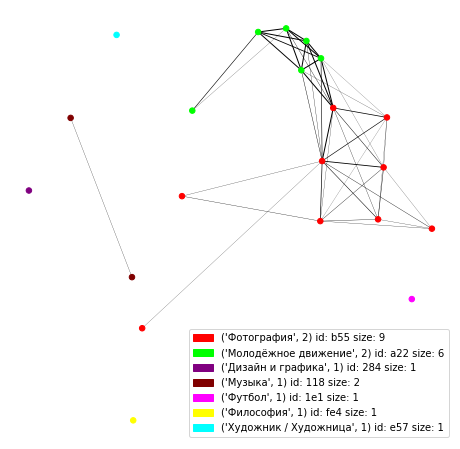

In [26]:
from main import *
import community
import networkx as nx
import matplotlib.pyplot as plt
user = VKUser('https://vk.com/destitutiones')
# Replace this with your networkx graph loading depending on your format !
G = user.groups.graph

#first compute the best partition
partition = community.best_partition(G)
clasters = dict()
for node, cls in partition.items():
    clasters[cls] = clasters.get(cls, []) + [node]
claster_pools = [GroupsPool(pool) for pool in list(clasters.values())]
print(len(claster_pools))
user.groups.color_graph(pools=claster_pools)
# user.groups.color_graph(algorithm='label_propagation')

In [29]:
id = '118'
print(bapi.get_obj(id).params['groups_pages_activity'])
print()
bapi.get_obj(id).print()

Counter({'Музыка': 1, 'Творчество': 1})

show MONICA 36495885 https://vk.com/showmonica
Eiro Nareth 111332195 https://vk.com/enareth


In [ ]:
|